# Interaction Term Model

## Step 1: Define the Full Model and Interaction Terms

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import RidgeCV

In [2]:
# Load processed data (already numeric/encoded)
df_train = pd.read_csv('../data/train_data/train_processed.csv')
target_col = 'Item_Outlet_Sales'
X = df_train.drop(columns=[target_col])
y = df_train[target_col]

print(f'Training rows: {df_train.shape[0]}')
print(f'Predictors: {X.shape[1]}')

Training rows: 6818
Predictors: 35


In [3]:
# Keep all main effects, then add a curated interaction set
cont_cols = [
    c for c in ['Item_MRP', 'Item_Weight', 'Item_Visibility', 'Outlet_Years']
    if c in X.columns
]
cat_cols = [c for c in X.columns if c not in cont_cols]

X_main = X.copy()

# Add all continuous x continuous interactions
cont_interactions = {}
for i, left in enumerate(cont_cols):
    for right in cont_cols[i + 1:]:
        cont_interactions[f'{left} * {right}'] = X[left] * X[right]

# Add continuous x categorical interactions
cont_cat_interactions = {}
for cont in cont_cols:
    for cat in cat_cols:
        cont_cat_interactions[f'{cont} * {cat}'] = X[cont] * X[cat]

# Add categorical x categorical interactions
cat_interactions = {}
for i, left in enumerate(cat_cols):
    for right in cat_cols[i + 1:]:
        cat_interactions[f'{left} * {right}'] = X[left] * X[right]

X_interactions = pd.DataFrame(
    {**cont_interactions, **cont_cat_interactions, **cat_interactions},
    index=X.index
)

X_full = pd.concat([X_main, X_interactions], axis=1)
feature_names = X_full.columns.to_numpy()
is_interaction = np.array([' * ' in name for name in feature_names])

num_main = X_main.shape[1]
num_cont_cont = len(cont_interactions)
num_cont_cat = len(cont_cat_interactions)
num_cat_cat = len(cat_interactions)
num_interactions = X_interactions.shape[1]

print('=== Curated Model Structure ===')
print(f'Main effects: {num_main}')
print(f'Continuous x continuous interactions: {num_cont_cont}')
print(f'Continuous x categorical interactions: {num_cont_cat}')
print(f'Categorical x categorical interactions: {num_cat_cat}')
print(f'Total curated interactions: {num_interactions}')
print(f'Total regressors: {X_full.shape[1]}')


=== Curated Model Structure ===
Main effects: 35
Continuous x continuous interactions: 6
Continuous x categorical interactions: 124
Categorical x categorical interactions: 465
Total curated interactions: 595
Total regressors: 630


In [4]:
# Fit a regularized linear model to inspect important interactions
alphas = np.logspace(-3, 3, 13)
ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_full, y)

coef = pd.Series(ridge.coef_, index=feature_names)
top_interactions = coef[is_interaction].abs().sort_values(ascending=False).head(20)

print('Selected alpha:', ridge.alpha_)
display(top_interactions.to_frame('abs_coefficient'))

Selected alpha: 100.0


,abs_coefficient
Outlet_Size * Outlet_Location_Type,0.350945
Outlet_Years * Outlet_Location_Type,0.240523
Outlet_Location_Type * Outlet_Type_Supermarket Type1,0.144592
Outlet_Years * Outlet_Type_Supermarket Type1,0.142174
Outlet_Size * Outlet_Type_Supermarket Type1,0.137047
Outlet_Years * Outlet_Identifier_OUT019,0.131730
Outlet_Location_Type * Outlet_Identifier_OUT019,0.119000
Outlet_Years * Outlet_Identifier_OUT027,0.109961
Outlet_Years * Outlet_Type_Supermarket Type3,0.109961
Outlet_Years * Outlet_Size,0.102904


## Step 2: Visualize Potential Interactions

In [5]:
# Use raw data for interpretable interaction plots
raw_df = pd.read_csv('../data/raw/big_mart_sales.csv')
plot_df = raw_df.dropna(subset=['Item_MRP', 'Item_Outlet_Sales', 'Outlet_Type', 'Outlet_Location_Type', 'Outlet_Size']).copy()

print(f'Rows used for interaction plots: {plot_df.shape[0]}')
sns.set_theme(style='whitegrid')

Rows used for interaction plots: 6113


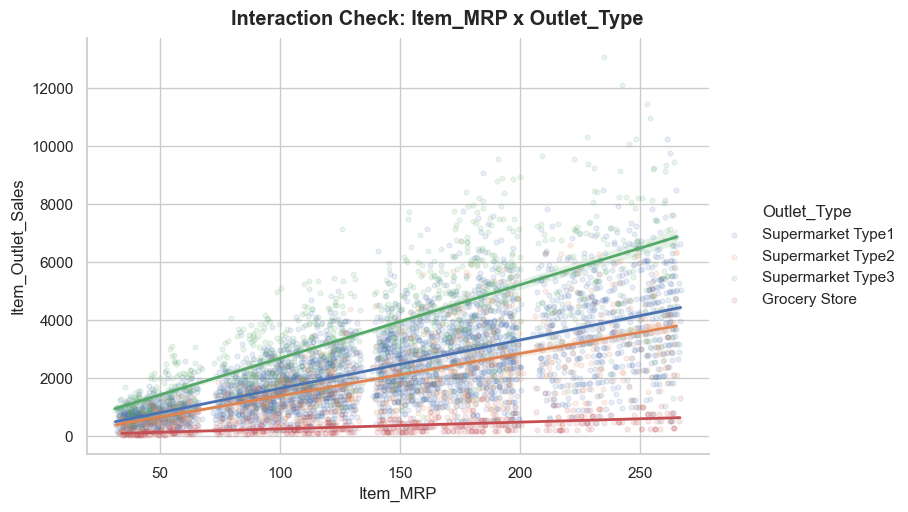

In [10]:
# Continuous x Categorical interaction check
g = sns.lmplot(
    data=plot_df,
    x='Item_MRP',
    y='Item_Outlet_Sales',
    hue='Outlet_Type',
    scatter_kws={'alpha': 0.12, 's': 12},
    line_kws={'linewidth': 2},
    height=5,
    aspect=1.5
)
g.fig.suptitle('Interaction Check: Item_MRP x Outlet_Type', y=1.02, fontweight='bold')
plt.show()

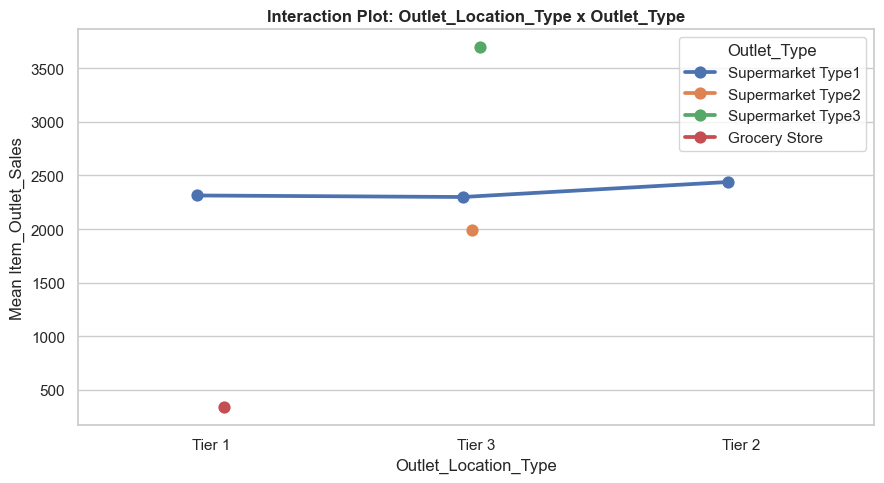

In [7]:
# Factorial-style interaction plot: Outlet_Location_Type x Outlet_Type
plt.figure(figsize=(9, 5))
sns.pointplot(
    data=plot_df,
    x='Outlet_Location_Type',
    y='Item_Outlet_Sales',
    hue='Outlet_Type',
    estimator=np.mean,
    errorbar=None,
    dodge=True
)
plt.title('Interaction Plot: Outlet_Location_Type x Outlet_Type', fontweight='bold')
plt.ylabel('Mean Item_Outlet_Sales')
plt.tight_layout()
plt.show()

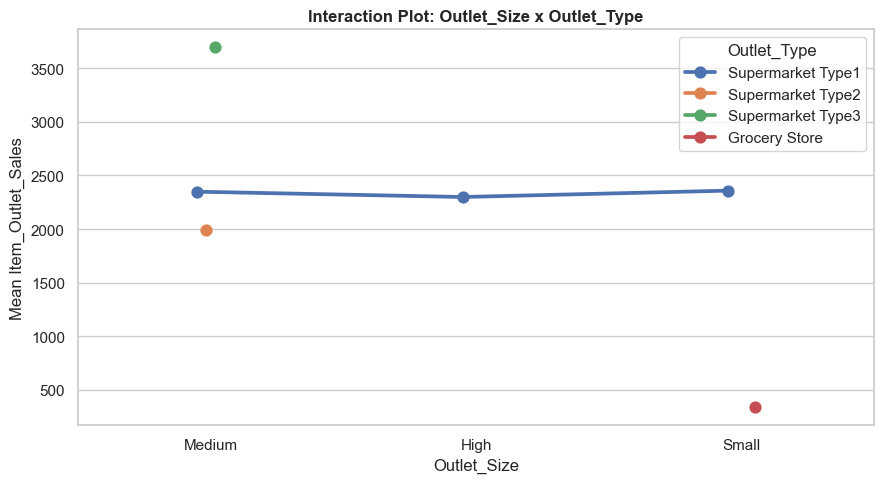

In [8]:
# Factorial-style interaction plot: Outlet_Size x Outlet_Type
plt.figure(figsize=(9, 5))
sns.pointplot(
    data=plot_df,
    x='Outlet_Size',
    y='Item_Outlet_Sales',
    hue='Outlet_Type',
    estimator=np.mean,
    errorbar=None,
    dodge=True
)
plt.title('Interaction Plot: Outlet_Size x Outlet_Type', fontweight='bold')
plt.ylabel('Mean Item_Outlet_Sales')
plt.tight_layout()
plt.show()

In [9]:
# Numeric check for non-parallel trend lines in the lmplot
print('Approximate slope of Sales vs MRP by Outlet_Type:')
for outlet_type, grp in plot_df.groupby('Outlet_Type'):
    if grp['Item_MRP'].nunique() > 2:
        slope = np.polyfit(grp['Item_MRP'], grp['Item_Outlet_Sales'], 1)[0]
        print(f'- {outlet_type}: {slope:.4f}')

Approximate slope of Sales vs MRP by Outlet_Type:
- Grocery Store: 2.3312
- Supermarket Type1: 16.7390
- Supermarket Type2: 14.6190
- Supermarket Type3: 25.3495
